In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Define tickers and date range
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-06-30'

# Fetch data
data = yf.download(tickers, start=start_date, end=end_date)
print("Data shape:", data.shape)
data.head()

[*********************100%***********************]  1 of 3 completed
[*********************100%***********************]  1 of 3 completed

Data shape: (2888, 15)


Price           Close                              High              \
Ticker            BND         SPY       TSLA        BND         SPY   
Date                                                                  
2015-01-02  59.405396  169.687866  14.620667  59.434147  170.885595   
2015-01-05  59.577923  166.623337  14.006000  59.599485  168.812266   
2015-01-06  59.750408  165.053925  14.085333  59.930098  167.449357   
2015-01-07  59.786339  167.110703  14.063333  59.858214  167.449371   
2015-01-08  59.692902  170.076096  14.041333  59.736025  170.290867   

Price                        Low                              Open  \
Ticker           TSLA        BND         SPY       TSLA        BND   
Date                                                                 
2015-01-02  14.883333  59.240079  168.655350  14.217333  59.247268   
2015-01-05  14.433333  59.441357  166.317716  13.810667  59.470108   
2015-01-06  14.280000  59.678533  164.260947  13.614000  59.678533   
2015-01-07  14.318667  59.692902  165.929510  13.985333  59.757588   
2015-01-08  14.253333  59.635400  168.498420  14.000667  59.736025   

Price                               Volume                       
Ticker             SPY       TSLA      BND        SPY      TSLA  
Date                                                             
2015-01-02  170.472589  14.858000  2218800  121465900  71466000  
2015-01-05  168.647066  14.303333  5820100  169632600  80527500  
2015-01-06  166.928965  14.004000  3887600  209151400  93928500  
2015-01-07  166.375551  14.223333  2433400  125346700  44526000  
2015-01-08  168.514931  14.187333  1873400  147217800  51637500

In [7]:
# Diagnostic: check what data we actually have
print("Data shape:", data.shape)
print("Data columns:", data.columns)
print("First 5 rows:\n", data.head())

Data shape: (2888, 15)
Data columns: MultiIndex([( 'Close',  'BND'),
            ( 'Close',  'SPY'),
            ( 'Close', 'TSLA'),
            (  'High',  'BND'),
            (  'High',  'SPY'),
            (  'High', 'TSLA'),
            (   'Low',  'BND'),
            (   'Low',  'SPY'),
            (   'Low', 'TSLA'),
            (  'Open',  'BND'),
            (  'Open',  'SPY'),
            (  'Open', 'TSLA'),
            ('Volume',  'BND'),
            ('Volume',  'SPY'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])
First 5 rows:
 Price           Close                              High              \
Ticker            BND         SPY       TSLA        BND         SPY   
Date                                                                  
2015-01-02  59.405396  169.687866  14.620667  59.434147  170.885595   
2015-01-05  59.577923  166.623337  14.006000  59.599485  168.812266   
2015-01-06  59.750408  165.053925  14.085333  59.930098  167.449357   
201

In [8]:
# Extract Close prices (adjusted for splits/dividends not needed here)
df = data['Close'].copy()
df.columns = tickers
print("Shape:", df.shape)
df.head()

Shape: (2888, 3)


,TSLA,BND,SPY
Date,,,
2015-01-02,59.405396,169.687866,14.620667
2015-01-05,59.577923,166.623337,14.006000
2015-01-06,59.750408,165.053925,14.085333
2015-01-07,59.786339,167.110703,14.063333
2015-01-08,59.692902,170.076096,14.041333


In [9]:
print("Summary statistics:\n", df.describe())

Summary statistics:
               TSLA          BND          SPY
count  2888.000000  2888.000000  2888.000000
mean     66.503053   351.505531   148.773923
std       4.713606   155.443935   138.895957
min      58.729198   154.161606     9.578000
25%      62.478077   223.546783    18.393499
50%      65.728416   312.817902   133.437668
75%      70.689137   432.806839   251.925831
max      74.832909   757.618225   489.880005


In [11]:
print("Missing values:\n", df.isnull().sum())
# Fill missing values using forward fill
df = df.ffill()
print("Missing values after fill:\n", df.isnull().sum())

Missing values:
 TSLA    0
BND     0
SPY     0
dtype: int64
Missing values after fill:
 TSLA    0
BND     0
SPY     0
dtype: int64


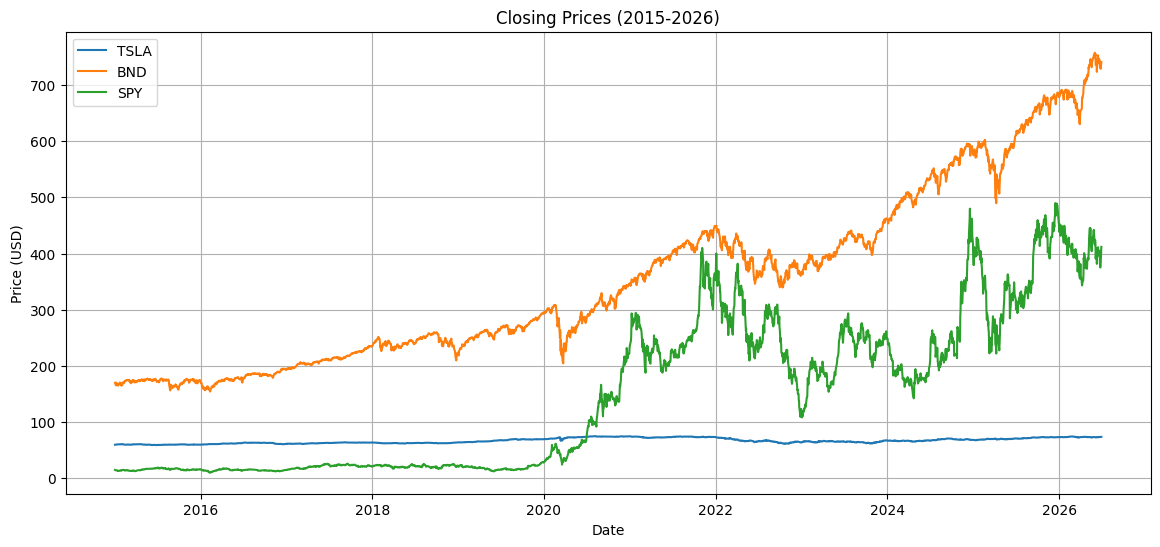

In [12]:
plt.figure(figsize=(14, 6))
for ticker in tickers:
    plt.plot(df.index, df[ticker], label=ticker)
plt.title('Closing Prices (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

Returns summary:
               TSLA          BND          SPY
count  2887.000000  2887.000000  2887.000000
mean      0.000079     0.000573     0.001803
std       0.003347     0.011121     0.036018
min      -0.054385    -0.109424    -0.210628
25%      -0.001511    -0.003700    -0.016643
50%       0.000134     0.000655     0.001216
75%       0.001773     0.005930     0.019456
max       0.042201     0.105019     0.226900


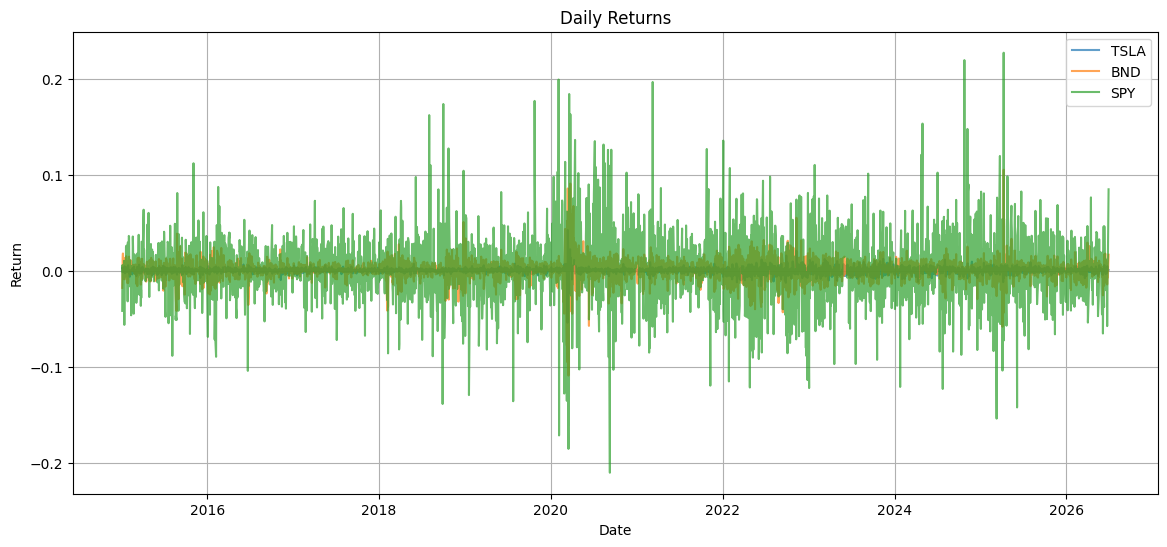

In [13]:
# Calculate daily returns
returns = df.pct_change().dropna()
print("Returns summary:\n", returns.describe())

# Plot returns
plt.figure(figsize=(14, 6))
for ticker in tickers:
    plt.plot(returns.index, returns[ticker], label=ticker, alpha=0.7)
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.show()

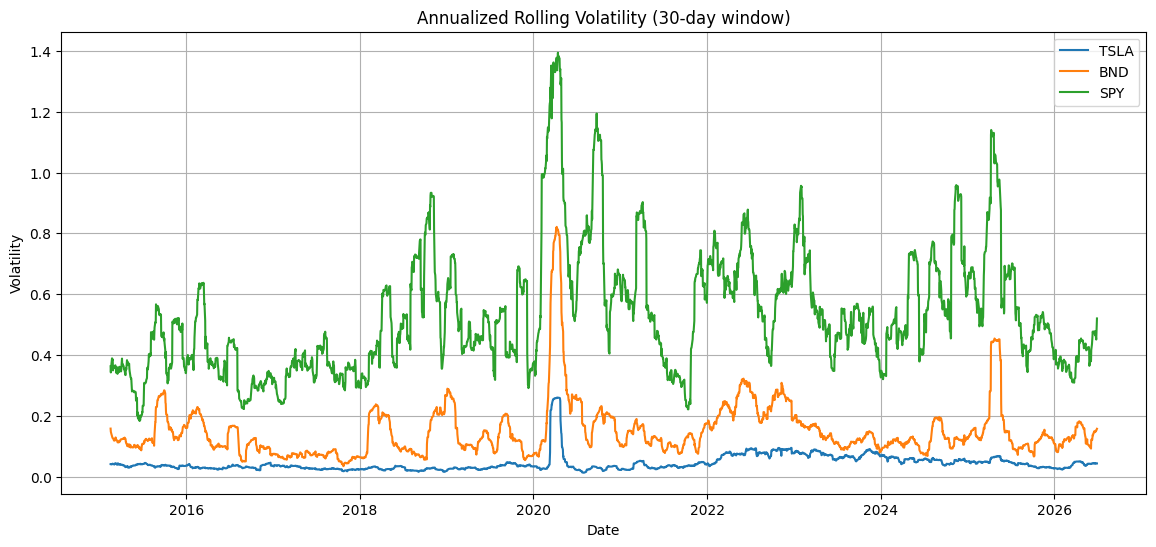

In [14]:
# Rolling 30-day volatility
rolling_vol = returns.rolling(30).std() * np.sqrt(252)  # annualized

plt.figure(figsize=(14, 6))
for ticker in tickers:
    plt.plot(rolling_vol.index, rolling_vol[ticker], label=ticker)
plt.title('Annualized Rolling Volatility (30-day window)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

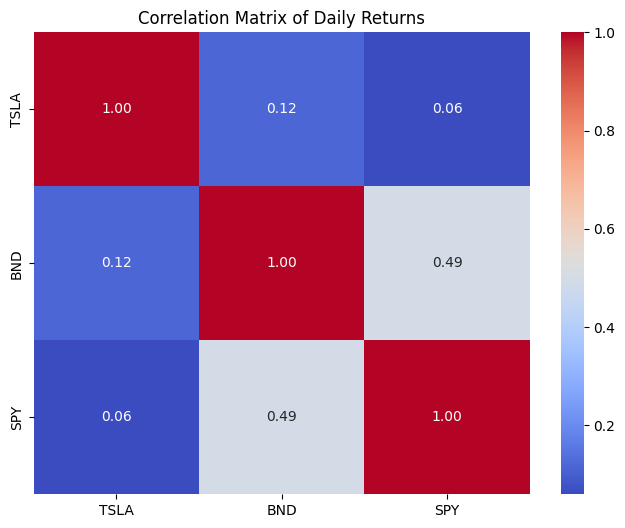

In [15]:
corr = returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Daily Returns')
plt.show()

In [16]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'{name}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.4f}')
    print('  Stationary' if result[1] < 0.05 else '  NOT Stationary')
    print('---')

for ticker in tickers:
    adf_test(df[ticker], ticker)
    adf_test(returns[ticker], f'{ticker} (returns)')

TSLA:
  ADF Statistic: -1.0827
  p-value: 0.7219
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
  NOT Stationary
---
TSLA (returns):
  ADF Statistic: -15.2160
  p-value: 0.0000
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
  Stationary
---
BND:
  ADF Statistic: 1.3089
  p-value: 0.9967
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
  NOT Stationary
---
BND (returns):
  ADF Statistic: -17.5722
  p-value: 0.0000
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
  Stationary
---
SPY:
  ADF Statistic: -1.0696
  p-value: 0.7270
  Critical Values:
    1%: -3.4326
    5%: -2.8626
    10%: -2.5673
  NOT Stationary
---
SPY (returns):
  ADF Statistic: -53.9719
  p-value: 0.0000
  Critical Values:
    1%: -3.4326
    5%: -2.8625
    10%: -2.5673
  Stationary
---


In [17]:
# Detect days with returns > 3 standard deviations
for ticker in tickers:
    mean = returns[ticker].mean()
    std = returns[ticker].std()
    outliers = returns[abs(returns[ticker] - mean) > 3 * std]
    print(f'{ticker}: {len(outliers)} outliers')
    print(outliers.head())

TSLA: 33 outliers
                TSLA       BND       SPY
Date                                    
2020-03-10 -0.013444  0.051745  0.061398
2020-03-11 -0.018940 -0.048749 -0.017200
2020-03-12 -0.054385 -0.095677 -0.116172
2020-03-13  0.042201  0.085486 -0.024851
2020-03-16  0.010511 -0.109424 -0.185778
BND: 39 outliers
                TSLA       BND       SPY
Date                                    
2015-08-24 -0.000245 -0.042107 -0.051567
2015-08-26 -0.004282  0.038394  0.021861
2016-06-24  0.005647 -0.035909 -0.016548
2018-02-05  0.004379 -0.041823 -0.030895
2018-02-08 -0.000751 -0.037509 -0.086290
SPY: 46 outliers
                TSLA       BND       SPY
Date                                    
2015-11-04  0.000615 -0.003033  0.111735
2018-08-02  0.000508  0.005448  0.161880
2018-08-07 -0.001772  0.003302  0.109886
2018-09-28  0.000000  0.000103 -0.139015
2018-10-01 -0.001872  0.003474  0.173471


In [18]:
# Calculate risk metrics
risk_metrics = {}

for ticker in tickers:
    # Sharpe ratio (annualized)
    sharpe = returns[ticker].mean() / returns[ticker].std() * np.sqrt(252)
    
    # Value at Risk (95% confidence)
    var_95 = np.percentile(returns[ticker], 5)
    
    risk_metrics[ticker] = {
        'Sharpe Ratio': sharpe,
        'VaR (95%)': var_95,
        'Volatility (annual)': returns[ticker].std() * np.sqrt(252)
    }

print(pd.DataFrame(risk_metrics).T)

      Sharpe Ratio  VaR (95%)  Volatility (annual)
TSLA      0.375587  -0.004757             0.053136
BND       0.817462  -0.016650             0.176547
SPY       0.794437  -0.051664             0.571775


## Key EDA Insights

1. **TSLA** has the highest volatility and returns – high risk, high reward.
2. **BND** is stable with low returns and low volatility – suitable for capital preservation.
3. **SPY** provides moderate returns with moderate risk – a balanced option.
4. **Returns are NOT stationary** (p > 0.05) – differencing is needed for ARIMA.
5. **Daily returns are stationary** (p < 0.05) – good for modeling.
6. **TSLA has the most outliers** – large price swings are common.
7. **BND is negatively correlated** with TSLA – useful for diversification.